In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [61]:
df = pd.read_csv(r"D:\SIT\Sem.5\Sugarcane yield prediction\Code\FINAL_SUGARCANE_DATASET.csv")

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Month                           2873 non-null   object 
 1   Temp_Min_C                      2857 non-null   float64
 2   Temp_Max_C                      2891 non-null   float64
 3   Temp_Avg_C                      2894 non-null   float64
 4   Rainfall_Total_mm               2878 non-null   float64
 5   Rainfall_Seasonal_mm            2891 non-null   float64
 6   Humidity_%                      2877 non-null   float64
 7   Solar_Radiation_MJ_m2_day       2874 non-null   float64
 8   Sunshine_Hours_hh_mm            2875 non-null   object 
 9   Wind_Speed_kmph                 2894 non-null   float64
 10  Evapotranspiration_mm_day       2891 non-null   float64
 11  Dew_Point_C                     2879 non-null   float64
 12  Heat_Stress_Days                28

In [63]:
df.isnull().sum()

Month                     127
Temp_Min_C                143
Temp_Max_C                109
Temp_Avg_C                106
Rainfall_Total_mm         122
                         ... 
District                    0
Year                       97
Season                    133
Growth_Stage              123
Yield_Quintal_per_Acre      0
Length: 70, dtype: int64

In [64]:
print(df.isnull().sum())

df = df.drop_duplicates()

Month                     127
Temp_Min_C                143
Temp_Max_C                109
Temp_Avg_C                106
Rainfall_Total_mm         122
                         ... 
District                    0
Year                       97
Season                    133
Growth_Stage              123
Yield_Quintal_per_Acre      0
Length: 70, dtype: int64


In [65]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Month', 'Temp_Min_C', 'Temp_Max_C', 'Temp_Avg_C', 'Rainfall_Total_mm', 'Rainfall_Seasonal_mm', 'Humidity_%', 'Solar_Radiation_MJ_m2_day', 'Sunshine_Hours_hh_mm', 'Wind_Speed_kmph', 'Evapotranspiration_mm_day', 'Dew_Point_C', 'Heat_Stress_Days', 'Frost_Days', 'Soil_Type', 'Soil_pH', 'EC', 'Organic_Carbon_%', 'Soil_Moisture_%', 'Sand_%', 'Silt_%', 'Clay_%', 'Soil_Depth_cm', 'Water_Holding_Capacity_%', 'Nitrogen_kg_per_acre', 'Phosphorus_kg_per_acre', 'Potassium_kg_per_acre', 'Zinc_mg_per_kg', 'Iron_mg_per_kg', 'Copper_mg_per_kg', 'Manganese_mg_per_kg', 'Sulfur_kg_per_acre', 'Irrigation_Frequency_Level', 'Water_Quantity_liters_per_acre', 'Irrigation_Method_Type', 'Groundwater_Level_meters', 'Water_Quality_Category', 'Crop_Duration_Days', 'Seed_Rate', 'Row_Spacing_cm', 'Row_Gap_cm', 'Plant_Density', 'Intercropping', 'Weed_Control', 'Soil_Condition_At_Planting', 'Planting_Method', 'Mulching', 'Fertilizer_Split', 'Drainage_Condition', 'Variety', 'Germination_%', 'Tillering_Co

In [66]:
print(df.dtypes)

Month                      object
Temp_Min_C                float64
Temp_Max_C                float64
Temp_Avg_C                float64
Rainfall_Total_mm         float64
                           ...   
District                   object
Year                      float64
Season                     object
Growth_Stage               object
Yield_Quintal_per_Acre    float64
Length: 70, dtype: object


In [67]:
print(df.describe(include="all").T)

                         count unique       top  freq         mean  \
Month                     2873     12       Jan   265          NaN   
Temp_Min_C              2857.0    NaN       NaN   NaN    22.352279   
Temp_Max_C              2891.0    NaN       NaN   NaN    33.361095   
Temp_Avg_C              2894.0    NaN       NaN   NaN    27.854239   
Rainfall_Total_mm       2878.0    NaN       NaN   NaN  1399.616508   
...                        ...    ...       ...   ...          ...   
District                  3000     14  Kolhapur   507          NaN   
Year                    2903.0    NaN       NaN   NaN   2020.94764   
Season                    2867      2    Kharif  1488          NaN   
Growth_Stage              2877      3     Early   989          NaN   
Yield_Quintal_per_Acre  3000.0    NaN       NaN   NaN   280.236656   

                               std         min          25%          50%  \
Month                          NaN         NaN          NaN          NaN   
Temp_Mi

In [68]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Month                 127
Temp_Min_C            143
Temp_Max_C            109
Temp_Avg_C            106
Rainfall_Total_mm     122
                     ... 
Application_Timing    120
Machinery_Use         117
Year                   97
Season                133
Growth_Stage          123
Length: 67, dtype: int64


Remove Duplicate Rows

In [69]:
# Check duplicate rows
print("Duplicates Before:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Check again
print("Duplicates After:", df.duplicated().sum())

print("Dataset Shape After Duplicate Removal:", df.shape)

Duplicates Before: 0
Duplicates After: 0
Dataset Shape After Duplicate Removal: (3000, 70)


Handle Missing Values

In [70]:
# Separate target column
target_column = "Yield_Quintal_per_Acre"

X = df.drop(columns=[target_column])
y = df[target_column]

# Identify numerical and categorical columns
numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:", len(numeric_columns))
print("Categorical Columns:", len(categorical_columns))

Numerical Columns: 45
Categorical Columns: 24


In [71]:
df_eda = df.copy()

# Numerical missing values -> Median
for col in numeric_columns:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

# Categorical missing values -> Mode
for col in categorical_columns:
    mode_value = df_eda[col].mode(dropna=True)

    if len(mode_value) > 0:
        df_eda[col] = df_eda[col].fillna(mode_value.iloc[0])
    else:
        df_eda[col] = df_eda[col].fillna("Unknown")

print("Remaining Missing Values:",
      df_eda.isnull().sum().sum())

Remaining Missing Values: 0


In [85]:
# def convert_to_hours(value):
#     if pd.isna(value):
#         return np.nan

#     try:
#         hours, minutes = map(int, str(value).split(":"))
#         return hours + minutes / 60
#     except:
#         return np.nan


# df_eda["Sunshine_Hours_Decimal"] = (
#     df_eda["Sunshine_Hours_hh_mm"]
#     .apply(convert_to_hours)
# )

# # Remove original text column
# df_eda = df_eda.drop(
#     columns=["Sunshine_Hours_hh_mm"]
# )

# print(df_eda["Sunshine_Hours_Decimal"].head())


# 2. Convert Sunshine Hours into Decimal Hours
def convert_to_hours(value):
    if pd.isna(value):
        return np.nan

    try:
        hours, minutes = map(int, str(value).split(":"))
        return hours + minutes / 60
    except:
        return np.nan


df["Sunshine_Hours_Decimal"] = (
    df["Sunshine_Hours_hh_mm"].apply(convert_to_hours)
)

# Remove the original time column
df = df.drop(columns=["Sunshine_Hours_hh_mm"])


# 3. Separate features and target
target_column = "Yield_Quintal_per_Acre"

X = df.drop(columns=[target_column])
y = df[target_column]


# 4. Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("Numerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numerical Features: 46
Categorical Features: 23


Outlier Detection

In [73]:
numeric_columns_eda = df_eda.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

outlier_summary = []

for col in numeric_columns_eda:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_eda[col] < lower_bound) |
        (df_eda[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Outlier_Count": outlier_count,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)

print(
    outlier_df.sort_values(
        "Outlier_Count",
        ascending=False
    ).head(20)
)

                       Column  Outlier_Count  Lower_Bound  Upper_Bound
45     Yield_Quintal_per_Acre              4   -21.109558   582.963777
1                  Temp_Max_C              0    11.777646    55.228506
0                  Temp_Min_C              0     0.744247    44.218959
3           Rainfall_Total_mm              0   298.321431  2493.755125
4        Rainfall_Seasonal_mm              0    13.392867  1567.218115
5                  Humidity_%              0    31.771772   108.555890
2                  Temp_Avg_C              0     5.750973    50.214441
7             Wind_Speed_kmph              0    -3.664462    20.824666
8   Evapotranspiration_mm_day              0    -0.673598    10.705661
9                 Dew_Point_C              0     3.059354    31.712209
10           Heat_Stress_Days              0   -15.500000    44.500000
11                 Frost_Days              0    -5.500000    14.500000
12                    Soil_pH              0     4.830375     9.682880
13    

Visualize outliers using boxplots

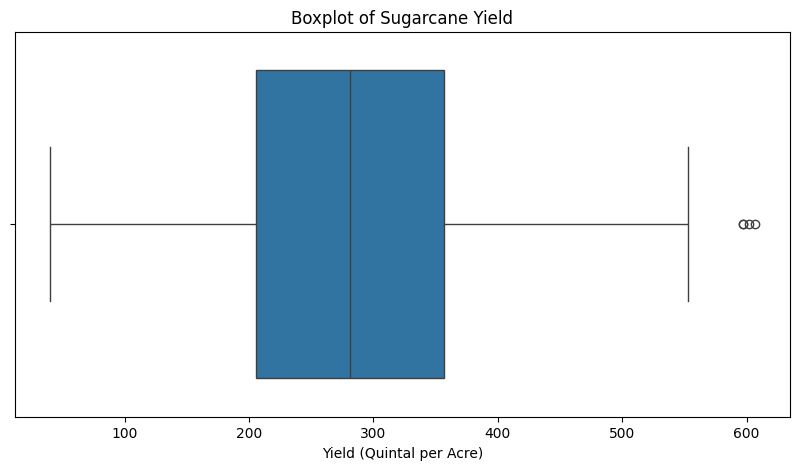

In [74]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df_eda["Yield_Quintal_per_Acre"]
)

plt.title("Boxplot of Sugarcane Yield")
plt.xlabel("Yield (Quintal per Acre)")

plt.show()

In [75]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Separate features and target
X = df.drop(columns=["Yield_Quintal_per_Acre"])
y = df["Yield_Quintal_per_Acre"]

# Convert sunshine hours before preprocessing
X["Sunshine_Hours_Decimal"] = (
    X["Sunshine_Hours_hh_mm"]
    .apply(convert_to_hours)
)

X = X.drop(columns=["Sunshine_Hours_hh_mm"])

# Identify columns again
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine transformations
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


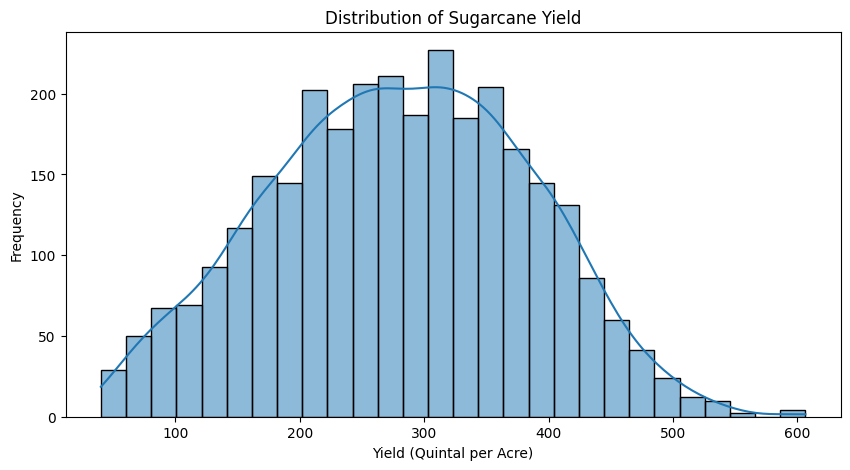

In [76]:
# Yield Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Yield_Quintal_per_Acre"],
    kde=True
)

plt.title("Distribution of Sugarcane Yield")
plt.xlabel("Yield (Quintal per Acre)")
plt.ylabel("Frequency")

plt.show()

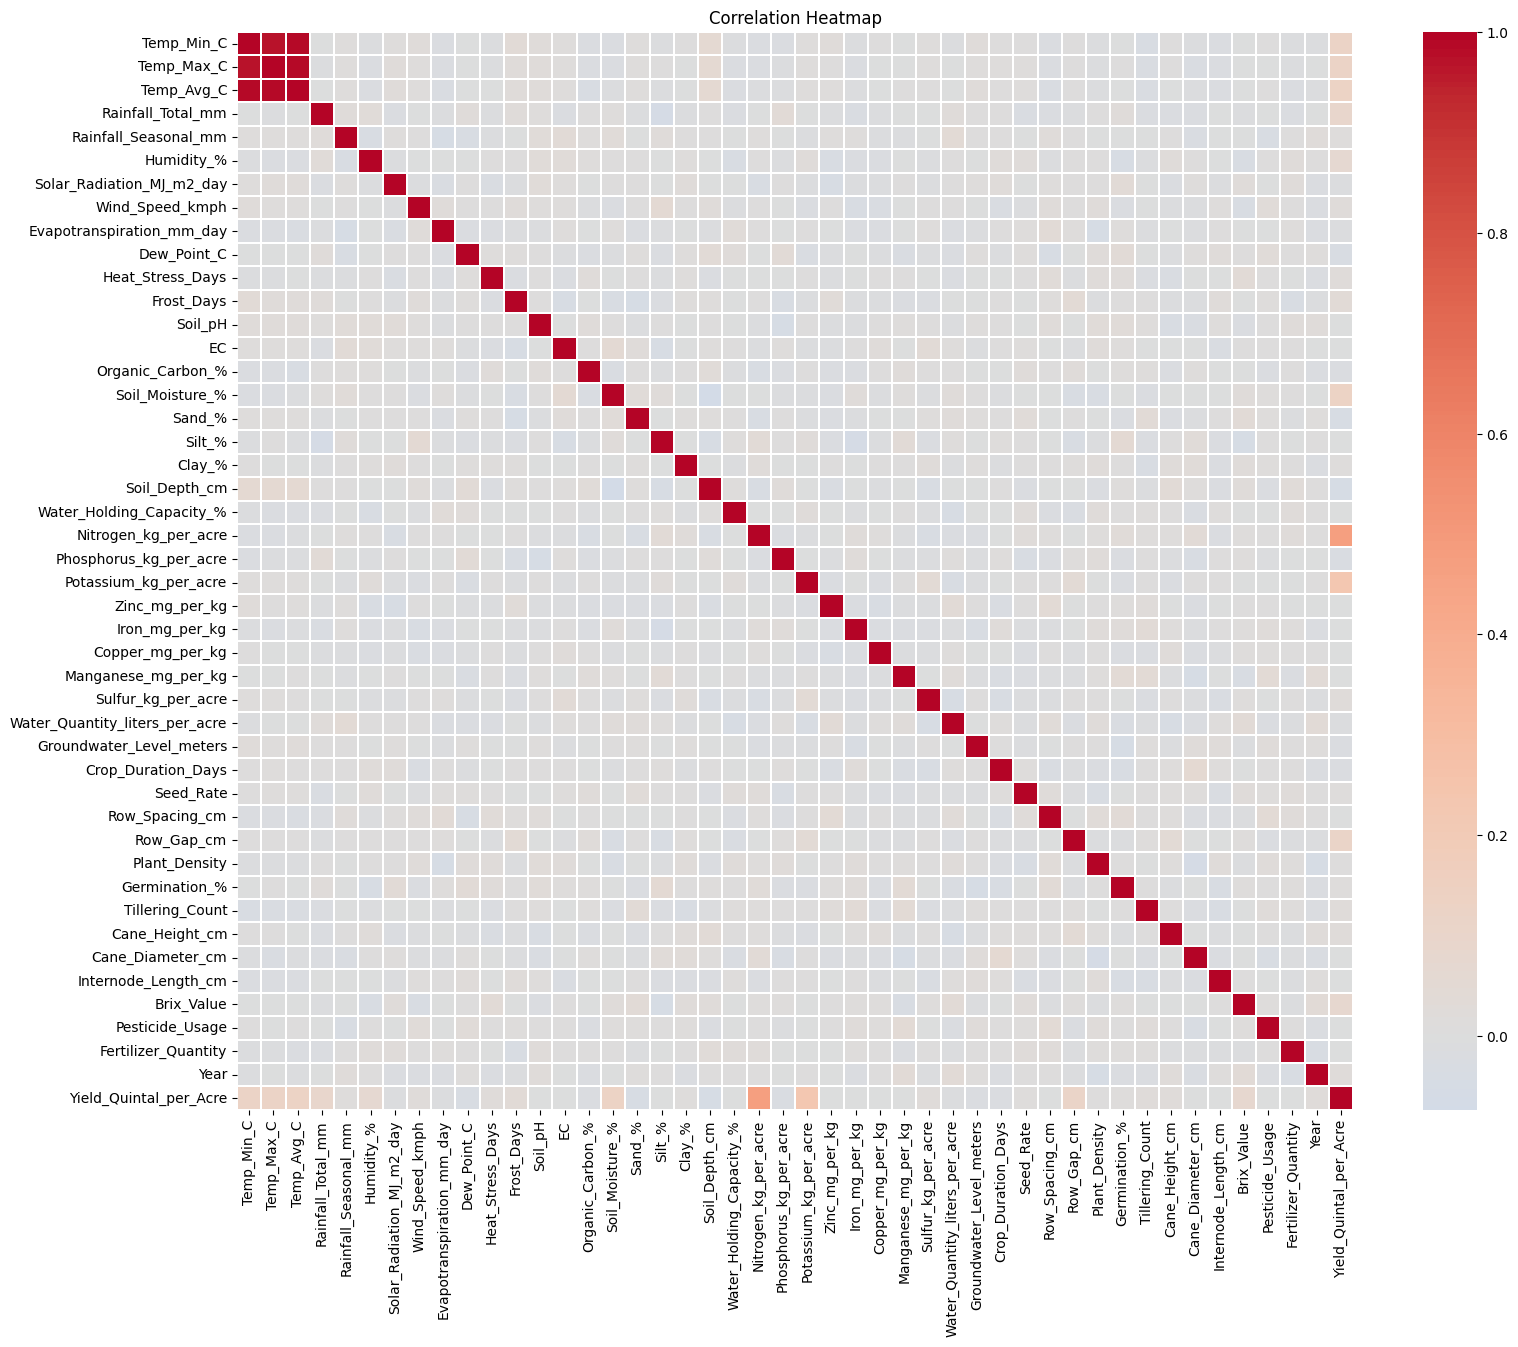

In [77]:
# Correlation Heatmap

plt.figure(figsize=(18, 14))

correlation = df.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap")
plt.show()

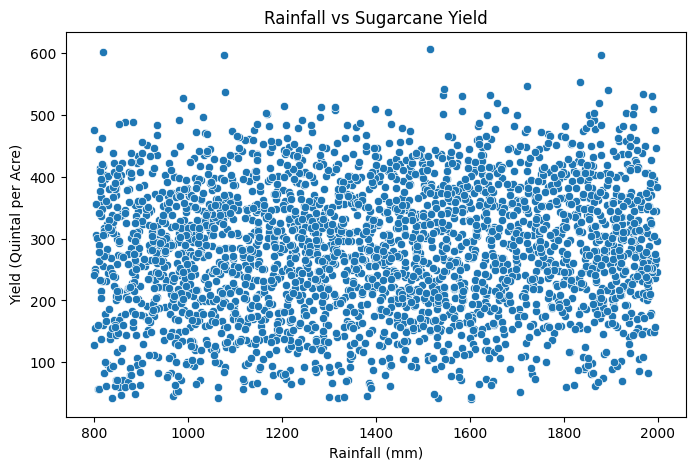

In [78]:
# Rainfall vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_Total_mm",
    y="Yield_Quintal_per_Acre"
)

plt.title("Rainfall vs Sugarcane Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Quintal per Acre)")

plt.show()



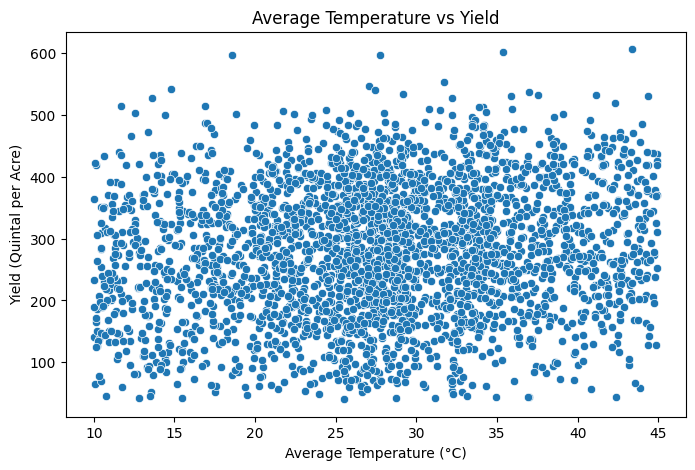

In [79]:
# Temperature vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Temp_Avg_C",
    y="Yield_Quintal_per_Acre"
)

plt.title("Average Temperature vs Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Quintal per Acre)")

plt.show()

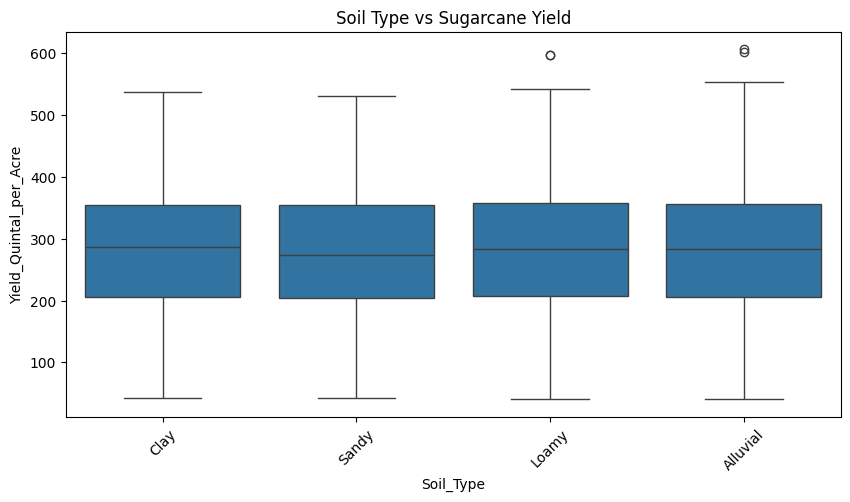

In [80]:
#5 Soil Type vs Yield

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Soil_Type",
    y="Yield_Quintal_per_Acre"
)

plt.title("Soil Type vs Sugarcane Yield")
plt.xticks(rotation=45)

plt.show()

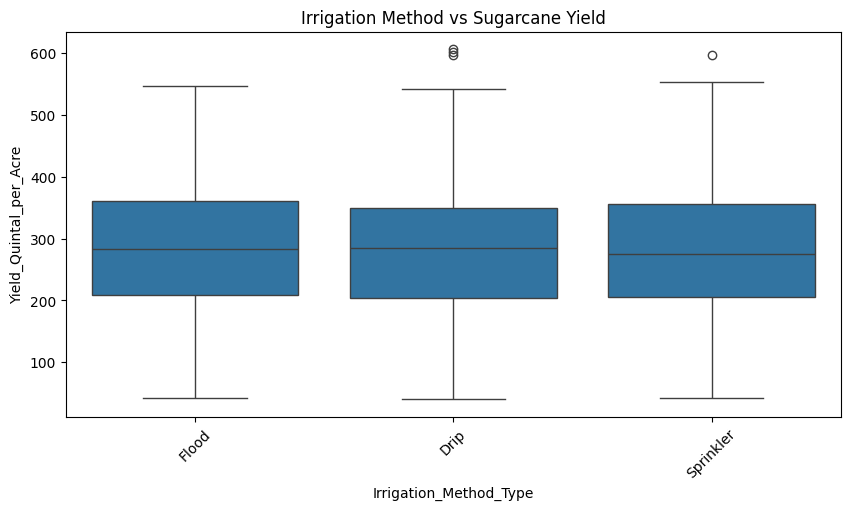

In [81]:
# Yield by Irrigation Method

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Irrigation_Method_Type",
    y="Yield_Quintal_per_Acre"
)

plt.title("Irrigation Method vs Sugarcane Yield")
plt.xticks(rotation=45)

plt.show()

In [86]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Yield_Quintal_per_Acre"])
y = df["Yield_Quintal_per_Acre"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2400, 69)
Testing Data: (600, 69)


In [83]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
model_pipeline.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [88]:
y_pred = model_pipeline.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[412.35403599 172.7678521  134.43803635 299.8609287  159.90385249
 259.31123717 404.41249536 205.44539736 116.71420807 359.78762178]


In [89]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 33.52409218982924
RMSE: 43.56591459520427
R2 Score: 0.8329373100956525
